# YZM212 Makine Öğrenmesi
## MLE ile Trafik Modelleme

Ad Soyad:İlayda Arslan

Öğrenci No:24290225

Tarih:15/03/2026

In [3]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from scipy.stats import poisson

## Bölüm 1: Teorik Çözüm

Poisson dağılımı belirli bir zaman aralığında gerçekleşen olay sayısını modellemek için kullanılır.

Poisson dağılımının olasılık kütle fonksiyonu:

P(k|λ) = (e^-λ * λ^k) / k!

Bir veri kümesi için likelihood fonksiyonu:

L(λ) = ∏ P(k_i | λ)

Log-likelihood:

ℓ(λ) = log L(λ)

ℓ(λ) = Σ(-λ + k_i log λ − log(k_i!))

ℓ(λ) = -nλ + (Σk_i) log λ − Σ log(k_i!)

Türev alınır:

dℓ/dλ = -n + (Σk_i)/λ

Türevi sıfıra eşitleyerek maksimum bulunur:

-n + (Σk_i)/λ = 0

Buradan:

λ = (1/n) Σk_i

Sonuç olarak Poisson dağılımı için MLE tahmini örneklem ortalamasına eşittir.

In [10]:
#gözlemlenen trafik verisi(1 dakikada geçen araç sayısı)
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15])

traffic_data

array([12, 15, 10,  8, 14, 11, 13, 16,  9, 12, 11, 14, 10, 15])

## Bölüm 2: Python ile Sayısal (Numerical) MLE

Bu bölümde negatif log-likelihood fonksiyonu tanımlanmış ve scipy.optimize kullanılarak λ parametresi tahmin edilmiştir.

In [11]:
# Negative Log-Likelihood fonksiyonu

def negative_log_likelihood(lam, data):
    
    lam = lam[0]
    
    if lam <= 0:
        return np.inf
    
    n = len(data)
    
    # k! sabit olduğu için ihmal edilir
    nll = n * lam - np.sum(data) * np.log(lam)
    
    return nll

In [12]:
# MLE tahmini

initial_guess = [1.0]

result = opt.minimize(
    negative_log_likelihood,
    initial_guess,
    args=(traffic_data,),
    bounds=[(0.001, None)]
)

mle_lambda = result.x[0]
sample_mean = np.mean(traffic_data)

print("Sayısal Tahmin (MLE lambda):", mle_lambda)
print("Analitik Tahmin (Veri Ortalaması):", sample_mean)

Sayısal Tahmin (MLE lambda): 12.14286136240759
Analitik Tahmin (Veri Ortalaması): 12.142857142857142


Sayısal optimizasyon ile elde edilen λ değeri veri ortalamasına eşittir. Bu durum Poisson dağılımı için Maximum Likelihood Estimation sonucunun örneklem ortalamasına eşit olduğunu doğrulamaktadır.

## Bölüm 3: Model Karşılaştırma ve Görselleştirme

Bu bölümde veri histogramı ile Poisson dağılımının olasılık kütle fonksiyonu birlikte gösterilmiştir.

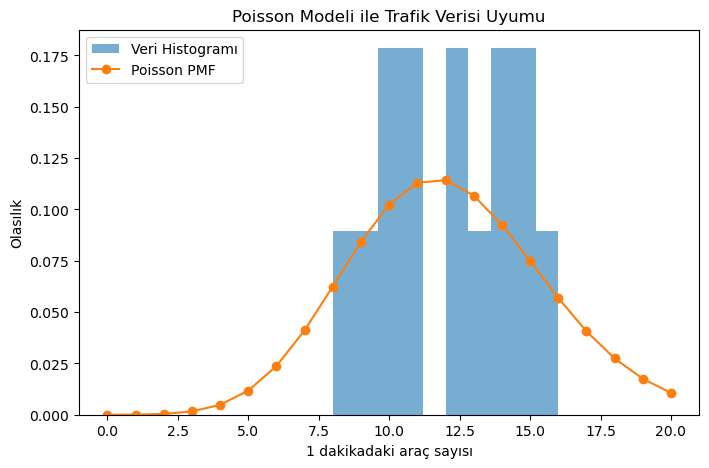

In [13]:
x = np.arange(0, max(traffic_data) + 5)

pmf_values = poisson.pmf(x, mle_lambda)

plt.figure(figsize=(8,5))

plt.hist(traffic_data, bins=10, density=True, alpha=0.6, label="Veri Histogramı")
plt.plot(x, pmf_values, 'o-', label="Poisson PMF")

plt.xlabel("1 dakikadaki araç sayısı")
plt.ylabel("Olasılık")
plt.title("Poisson Modeli ile Trafik Verisi Uyumu")

plt.legend()

plt.show()

Grafik incelendiğinde Poisson dağılımının veri ile genel olarak uyumlu olduğu görülmektedir. Araç sayıları ortalama etrafında yoğunlaşmaktadır.

## Bölüm 4: Outlier (Aykırı Değer) Analizi

Veri setine hatalı kaydedilmiş olabilecek büyük bir değer eklenmiştir.

In [7]:
traffic_data_outlier = np.append(traffic_data, 200)

result_outlier = opt.minimize(
    negative_log_likelihood,
    [1.0],
    args=(traffic_data_outlier,),
    bounds=[(0.001, None)]
)

mle_lambda_outlier = result_outlier.x[0]
mean_outlier = np.mean(traffic_data_outlier)

print("Outlier sonrası MLE:", mle_lambda_outlier)
print("Outlier sonrası ortalama:", mean_outlier)

Outlier sonrası MLE: 24.666684254362178
Outlier sonrası ortalama: 24.666666666666668


Veri setine 200 gibi aşırı büyük bir değer eklendiğinde ortalama ciddi şekilde artmaktadır. Poisson dağılımında MLE tahmini doğrudan ortalamaya eşit olduğu için model parametresi bu değerden önemli ölçüde etkilenir. Bu durum MLE yönteminin aykırı değerlere karşı hassas olduğunu göstermektedir.